In [4]:
from mscg import *
#import torch
#import torch_geometric
print("OpenMSCG ready")
#print("Torch:", torch.__version__)

OpenMSCG ready


In [5]:
AA_traj = Trajectory('traj.trr', fmt='trr')
AA_traj.read_frame()
AA_traj.x.shape

(10368, 3)

In [ ]:
from mscg.cli import cgmap

# map atomistic traj to CG traj
cgmap.main(map='map.yaml', traj='traj.trr', out='CG.lammpstrj')

In [ ]:
# creating the potential using force matching
# tabulated potential that can be used by lammps
from mscg.cli import cgfm

cgfm.main(
    top     = "cg.top",
    traj    = "CG.lammpstrj",
    cut     = 10.0,
    pair    = ['model=BSpline,type=MeOH:MeOH,min=2.8,max=10.0,resolution=0.1,order=3']
)

In [8]:
from mscg.cli import cgdump

cgdump.main(
    file = "result.p",
    dump = ['Pair_MeOH-MeOH,0.05,10.0,0.05,L2']
)

(-2.0, 6.0)

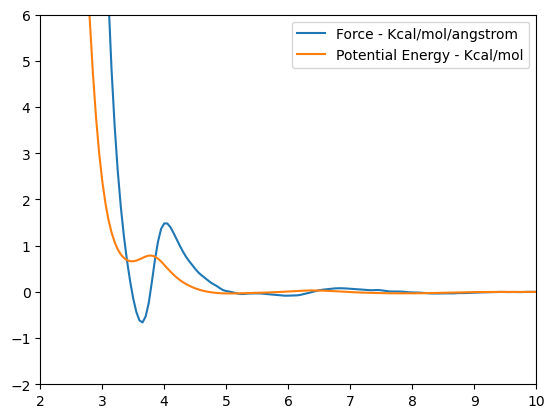

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt

table = np.loadtxt('Pair_MeOH-MeOH.table', skiprows=5)

plt.plot(table[:,1], table[:,3], label='Force - Kcal/mol/angstrom')
plt.plot(table[:,1], table[:,2], label='Potential Energy - Kcal/mol')

plt.legend(loc='upper right')
plt.xlim(2, 10)
plt.ylim(-2, 6)